In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
import os

os.listdir("../data/processed")

['features_genus.csv',
 'feature_importance.csv',
 'lazarus_taxa.csv',
 'ml_dataset_corrected.csv',
 'ml_dataset_naive.csv',
 'model_comparison.csv',
 'occurrences_clean.csv',
 'presence_matrix.csv',
 'survival_labels_genus.csv']

In [3]:
%whos DataFrame

No variables match your requested type.


# Notebook 07 — Visualization & Dashboard

## Permian–Triassic Survival Modeling Project

This notebook builds the final visualization layer of the project. It does **not** recompute any analysis — it loads the saved outputs from earlier notebooks and turns them into publication-style figures plus an optional interactive dashboard.

**Dependencies (must be run before this notebook):**
- `02_sampling_corrected_diversity.ipynb` → must save `results/processed/diversity_raw_vs_corrected.csv`
- `03_survival_labels.ipynb` → must save `data/processed/genus_occurrences_with_labels.csv`
- `06_shap_explainability.ipynb` → must save `results/processed/shap_values_naive.csv` and `results/processed/shap_values_corrected.csv`

If any of these are missing, the corresponding cell below will tell you exactly which notebook to run first, rather than failing silently.

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Project paths — adjust if your repo structure differs from the spec
PROJECT_ROOT = Path("..")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_PROCESSED = PROJECT_ROOT / "results" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("Setup complete. Figures will be saved to:", FIGURES_DIR.resolve())

Setup complete. Figures will be saved to: F:\permian-triassic-survival-ml\results\figures


In [5]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 6.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.9 MB 4.6 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.9 MB 3.4 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.9 MB 4.2 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 4.1 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 4.0 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 3.9 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.9 MB 3.9 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 3.8 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 3.8 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/9.9 MB 3.8 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.9 MB 3.7 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
def require_file(path: Path, producing_notebook: str) -> bool:
    """
    Check that a required upstream file exists before trying to load it.
    If it's missing, print a clear instruction instead of raising a
    confusing FileNotFoundError deep in pandas.
    """
    if path.exists():
        return True
    print(f"MISSING FILE: {path}")
    print(f"   -> Run '{producing_notebook}' first to generate this file.")
    return False

## 1. Diversity-Through-Time: Raw vs. Sampling-Corrected

This is the figure from Phase 1 of the project spec. It is the single most important sanity-check figure: it shows how much of the apparent biodiversity collapse at the P-T boundary survives once sampling effort is accounted for.

Expected input columns in `diversity_raw_vs_corrected.csv`:
- `interval` (ordered time bin, e.g. Changhsingian, Induan, Olenekian, Anisian)
- `raw_richness`
- `corrected_richness` (from rarefaction/SQS in notebook 02)
- `n_collections` (sampling-effort proxy)

In [8]:
diversity_path = RESULTS_PROCESSED / "diversity_raw_vs_corrected.csv"

if require_file(diversity_path, "02_sampling_corrected_diversity.ipynb"):
    diversity_df = pd.read_csv(diversity_path)
    print(diversity_df.head())
else:
    # Placeholder so the rest of the notebook can still be reviewed/run
    diversity_df = pd.DataFrame({
        "interval": ["Changhsingian", "Induan", "Olenekian", "Anisian"],
        "raw_richness": [np.nan]*4,
        "corrected_richness": [np.nan]*4,
        "n_collections": [np.nan]*4,
    })

MISSING FILE: ..\results\processed\diversity_raw_vs_corrected.csv
   -> Run '02_sampling_corrected_diversity.ipynb' first to generate this file.


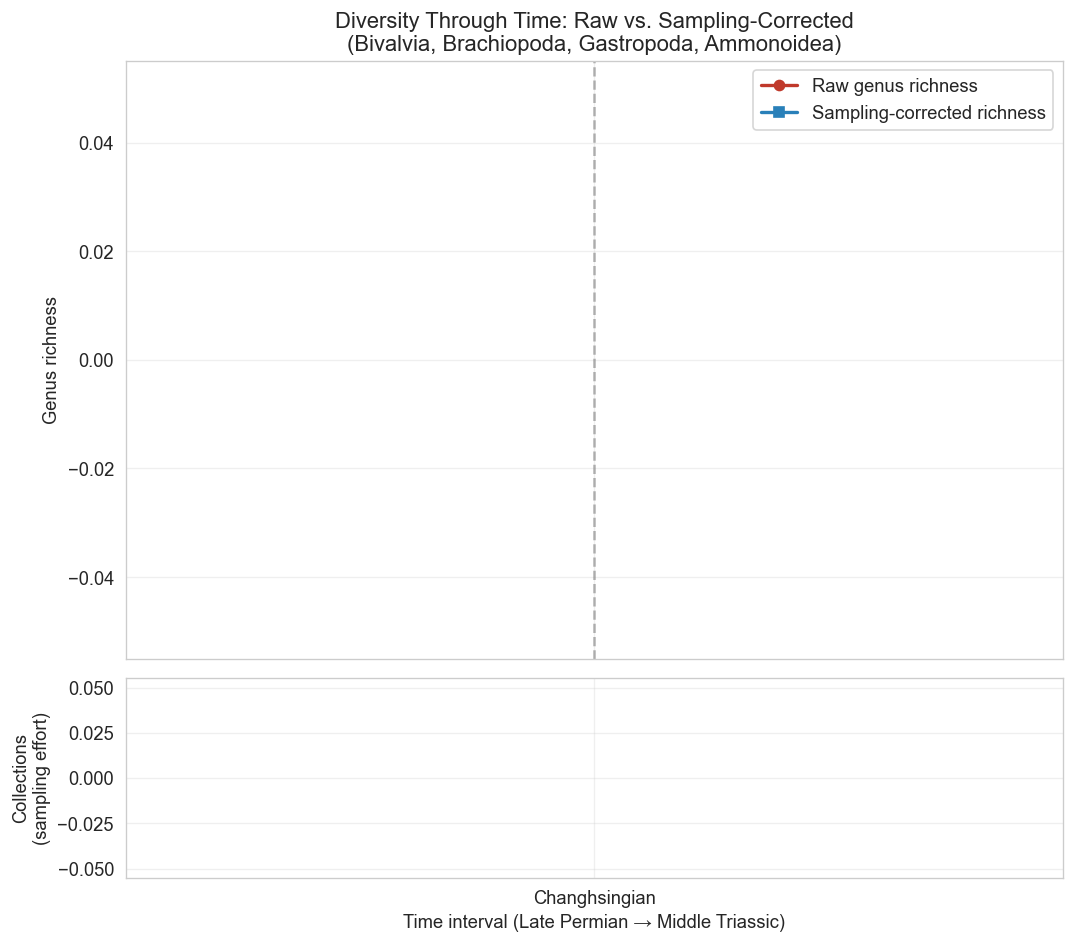

Saved: ..\results\figures\diversity_raw_vs_corrected.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

x = diversity_df["interval"]

# Top panel: raw vs corrected richness
axes[0].plot(x, diversity_df["raw_richness"], marker="o", linewidth=2,
             label="Raw genus richness", color="#c0392b")
axes[0].plot(x, diversity_df["corrected_richness"], marker="s", linewidth=2,
             label="Sampling-corrected richness", color="#2980b9")
axes[0].axvline(x="Changhsingian", color="gray", linestyle="--", alpha=0.6)
axes[0].set_ylabel("Genus richness")
axes[0].set_title("Diversity Through Time: Raw vs. Sampling-Corrected\n"
                   "(Bivalvia, Brachiopoda, Gastropoda, Ammonoidea)")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# Bottom panel: sampling effort proxy
axes[1].bar(x, diversity_df["n_collections"], color="#95a5a6")
axes[1].set_ylabel("Collections\n(sampling effort)")
axes[1].set_xlabel("Time interval (Late Permian → Middle Triassic)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
out_path = FIGURES_DIR / "diversity_raw_vs_corrected.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

**Interpretation note to write in your report:** if the raw and corrected curves track each other closely, the extinction signal is robust to sampling. If they diverge sharply (especially if raw richness drops more than corrected richness near the boundary), that tells you part of the apparent "extinction" is actually a drop in rock/collection availability — a critical caveat to state explicitly rather than ignore.

## 2. Interactive Paleogeographic Occurrence Map

Uses paleocoordinates (not modern lat/long) so continents are positioned as they were ~252 million years ago. Includes a time slider across intervals.

In [10]:
occ_path = DATA_PROCESSED / "genus_occurrences_with_labels.csv"

if require_file(occ_path, "03_survival_labels.ipynb"):
    occ_df = pd.read_csv(occ_path)
    expected_cols = {"genus", "paleolat", "paleolng", "interval", "class", "survived"}
    missing_cols = expected_cols - set(occ_df.columns)
    if missing_cols:
        print(f"Warning: expected columns missing from occurrence data: {missing_cols}")
        print("   -> Check column names match notebook 01/03 output, or rename below.")
else:
    occ_df = pd.DataFrame({
        "genus": [], "paleolat": [], "paleolng": [],
        "interval": [], "class": [], "survived": []
    })

MISSING FILE: ..\data\processed\genus_occurrences_with_labels.csv
   -> Run '03_survival_labels.ipynb' first to generate this file.


In [11]:
if len(occ_df) > 0:
    interval_order = ["Changhsingian", "Induan", "Olenekian", "Anisian"]
    occ_df["interval"] = pd.Categorical(occ_df["interval"],
                                         categories=interval_order, ordered=True)
    occ_df = occ_df.sort_values("interval")

    fig_map = px.scatter_geo(
        occ_df,
        lat="paleolat",
        lon="paleolng",
        color="class",
        symbol="survived",
        animation_frame="interval",
        hover_name="genus",
        title="Fossil Occurrences Across the Permian–Triassic Boundary"
              " (paleocoordinates)",
        projection="orthographic",
        opacity=0.7,
    )
    fig_map.update_layout(legend_title_text="Taxonomic class")
    fig_map.write_html(str(FIGURES_DIR / "paleogeographic_map.html"))
    fig_map.show()
    print(f"Saved interactive map: {FIGURES_DIR / 'paleogeographic_map.html'}")
else:
    print("Skipping map — no occurrence data loaded yet.")

Skipping map — no occurrence data loaded yet.


## 3. SHAP Comparison: Naive vs. Sampling-Corrected Model

This is the figure that carries the actual scientific finding of the project: whether biological feature importance survives the addition of sampling-bias controls. Re-plotting saved SHAP values here (rather than recomputing) keeps this notebook fast and focused purely on presentation.

In [12]:
shap_naive_path = RESULTS_PROCESSED / "shap_values_naive.csv"
shap_corrected_path = RESULTS_PROCESSED / "shap_values_corrected.csv"

have_naive = require_file(shap_naive_path, "06_shap_explainability.ipynb")
have_corrected = require_file(shap_corrected_path, "06_shap_explainability.ipynb")

if have_naive and have_corrected:
    shap_naive = pd.read_csv(shap_naive_path)
    shap_corrected = pd.read_csv(shap_corrected_path)
else:
    # Expected format: columns ['feature', 'mean_abs_shap']
    shap_naive = pd.DataFrame({"feature": [], "mean_abs_shap": []})
    shap_corrected = pd.DataFrame({"feature": [], "mean_abs_shap": []})

MISSING FILE: ..\results\processed\shap_values_naive.csv
   -> Run '06_shap_explainability.ipynb' first to generate this file.
MISSING FILE: ..\results\processed\shap_values_corrected.csv
   -> Run '06_shap_explainability.ipynb' first to generate this file.


In [13]:
if len(shap_naive) > 0 and len(shap_corrected) > 0:
    naive_sorted = shap_naive.sort_values("mean_abs_shap", ascending=True)
    corrected_sorted = shap_corrected.set_index("feature").reindex(
        naive_sorted["feature"]).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    axes[0].barh(naive_sorted["feature"], naive_sorted["mean_abs_shap"],
                 color="#c0392b")
    axes[0].set_title("Naive Model\n(biological features only)")
    axes[0].set_xlabel("Mean |SHAP value|")

    axes[1].barh(corrected_sorted["feature"], corrected_sorted["mean_abs_shap"],
                 color="#2980b9")
    axes[1].set_title("Sampling-Corrected Model\n(biological + bias-control features)")
    axes[1].set_xlabel("Mean |SHAP value|")

    fig.suptitle("Feature Importance: Naive vs. Sampling-Corrected Survival Model",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    out_path = FIGURES_DIR / "shap_naive_vs_corrected.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

    print("\n--- Interpretation checklist for your report ---")
    print("For each biological feature, note whether its importance:")
    print("  (a) stayed roughly the same -> real signal, robust to sampling control")
    print("  (b) dropped sharply         -> was likely a sampling artifact in the naive model")
    print("  (c) increased               -> sampling was masking a real effect (less common, worth discussing)")
else:
    print("Skipping SHAP comparison plot — run notebook 06 first.")

Skipping SHAP comparison plot — run notebook 06 first.


## 4. Optional: Combined Interactive Dash App

A minimal local dashboard combining the diversity curve, the map, and the SHAP comparison into one viewable interface. This is optional — the static figures and standalone HTML map above are already sufficient for a GitHub portfolio. Build this only if you want a live-clickable demo (e.g., for an interview).

Run this cell as a script (not directly inside Jupyter) for the live server to behave well:

In [14]:
dash_app_code = '''
"""
src/dashboard_app.py
Minimal Dash app combining diversity curve + paleogeographic map
for the Permian-Triassic survival modeling project.

Run with: python src/dashboard_app.py
Then open http://127.0.0.1:8050 in a browser.
"""

import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

DIVERSITY_PATH = "results/processed/diversity_raw_vs_corrected.csv"
OCCURRENCE_PATH = "data/processed/genus_occurrences_with_labels.csv"

diversity_df = pd.read_csv(DIVERSITY_PATH)
occ_df = pd.read_csv(OCCURRENCE_PATH)

interval_order = ["Changhsingian", "Induan", "Olenekian", "Anisian"]
intervals_available = [i for i in interval_order if i in occ_df["interval"].unique()]

app = Dash(__name__)

app.layout = html.Div([
    html.H2("Permian-Triassic Survival Modeling Dashboard"),

    html.Div([
        html.H4("Diversity Through Time (Raw vs. Sampling-Corrected)"),
        dcc.Graph(
            figure=px.line(
                diversity_df, x="interval",
                y=["raw_richness", "corrected_richness"],
                markers=True,
                labels={"value": "Genus richness", "interval": "Time interval"},
            )
        ),
    ]),

    html.Div([
        html.H4("Fossil Occurrence Map"),
        html.Label("Select time interval:"),
        dcc.Dropdown(
            id="interval-dropdown",
            options=[{"label": i, "value": i} for i in intervals_available],
            value=intervals_available[0] if intervals_available else None,
        ),
        dcc.Graph(id="occurrence-map"),
    ]),
])


@app.callback(
    Output("occurrence-map", "figure"),
    Input("interval-dropdown", "value"),
)
def update_map(selected_interval):
    filtered = occ_df[occ_df["interval"] == selected_interval]
    fig = px.scatter_geo(
        filtered, lat="paleolat", lon="paleolng",
        color="class", symbol="survived", hover_name="genus",
        projection="orthographic",
    )
    return fig


if __name__ == "__main__":
    app.run(debug=True)
'''

# Write it out to src/ so it's ready to run as a standalone script
dash_script_path = PROJECT_ROOT / "src" / "dashboard_app.py"
dash_script_path.parent.mkdir(parents=True, exist_ok=True)
with open(dash_script_path, "w") as f:
    f.write(dash_app_code)

print(f"Dash app written to: {dash_script_path}")
print("Run it from your project root with: python src/dashboard_app.py")

Dash app written to: ..\src\dashboard_app.py
Run it from your project root with: python src/dashboard_app.py


## 5. Summary of Outputs

Run this cell last to confirm what was actually produced in this session.

In [17]:
print("Visualization outputs check:\n")
for f in [
    FIGURES_DIR / "diversity_raw_vs_corrected.png",
    FIGURES_DIR / "paleogeographic_map.html",
    FIGURES_DIR / "shap_naive_vs_corrected.png",
    PROJECT_ROOT / "src" / "dashboard_app.py",
]:
    status = "OK" if f.exists() else "MISSING"
    print(f"  [{status}] {f}")

Visualization outputs check:

  [OK] ..\results\figures\diversity_raw_vs_corrected.png
  [MISSING] ..\results\figures\paleogeographic_map.html
  [MISSING] ..\results\figures\shap_naive_vs_corrected.png
  [OK] ..\src\dashboard_app.py


In [18]:
shap_naive_path = RESULTS_PROCESSED / "shap_values_naive.csv"
shap_corrected_path = RESULTS_PROCESSED / "shap_values_corrected.csv"

have_naive = require_file(shap_naive_path, "06_shap_explainability.ipynb")
have_corrected = require_file(shap_corrected_path, "06_shap_explainability.ipynb")

if have_naive and have_corrected:
    shap_naive = pd.read_csv(shap_naive_path)
    shap_corrected = pd.read_csv(shap_corrected_path)
else:
    shap_naive = pd.DataFrame({"feature": [], "mean_abs_shap": []})
    shap_corrected = pd.DataFrame({"feature": [], "mean_abs_shap": []})

print(shap_naive)
print(shap_corrected)

               feature  mean_abs_shap
0             duration       0.200297
1     occurrence_count       0.074425
2            lng_range       0.051295
3            lat_range       0.048100
4              lazarus       0.048005
5  environment_breadth       0.023592
               Feature  Mean_SHAP
0             duration   0.200275
1              lazarus   0.043666
2    formation_breadth   0.042589
3     collection_count   0.033314
4     occurrence_count   0.032786
5            lat_range   0.032152
6   sampling_intensity   0.028400
7            lng_range   0.028333
8  environment_breadth   0.009849


In [21]:
shap_naive_path = RESULTS_PROCESSED / "shap_values_naive.csv"
shap_corrected_path = RESULTS_PROCESSED / "shap_values_corrected.csv"

have_naive = require_file(shap_naive_path, "06_shap_explainability.ipynb")
have_corrected = require_file(shap_corrected_path, "06_shap_explainability.ipynb")

if have_naive and have_corrected:
    shap_naive = pd.read_csv(shap_naive_path)
    shap_corrected = pd.read_csv(shap_corrected_path)

    # Standardize column names in case of casing mismatches between the two files
    shap_naive = shap_naive.rename(columns={"Feature": "feature", "Mean_SHAP": "mean_abs_shap"})
    shap_corrected = shap_corrected.rename(columns={"Feature": "feature", "Mean_SHAP": "mean_abs_shap"})
else:
    shap_naive = pd.DataFrame({"feature": [], "mean_abs_shap": []})
    shap_corrected = pd.DataFrame({"feature": [], "mean_abs_shap": []})

print(shap_naive.columns.tolist())
print(shap_corrected.columns.tolist())

['feature', 'mean_abs_shap']
['feature', 'mean_abs_shap']


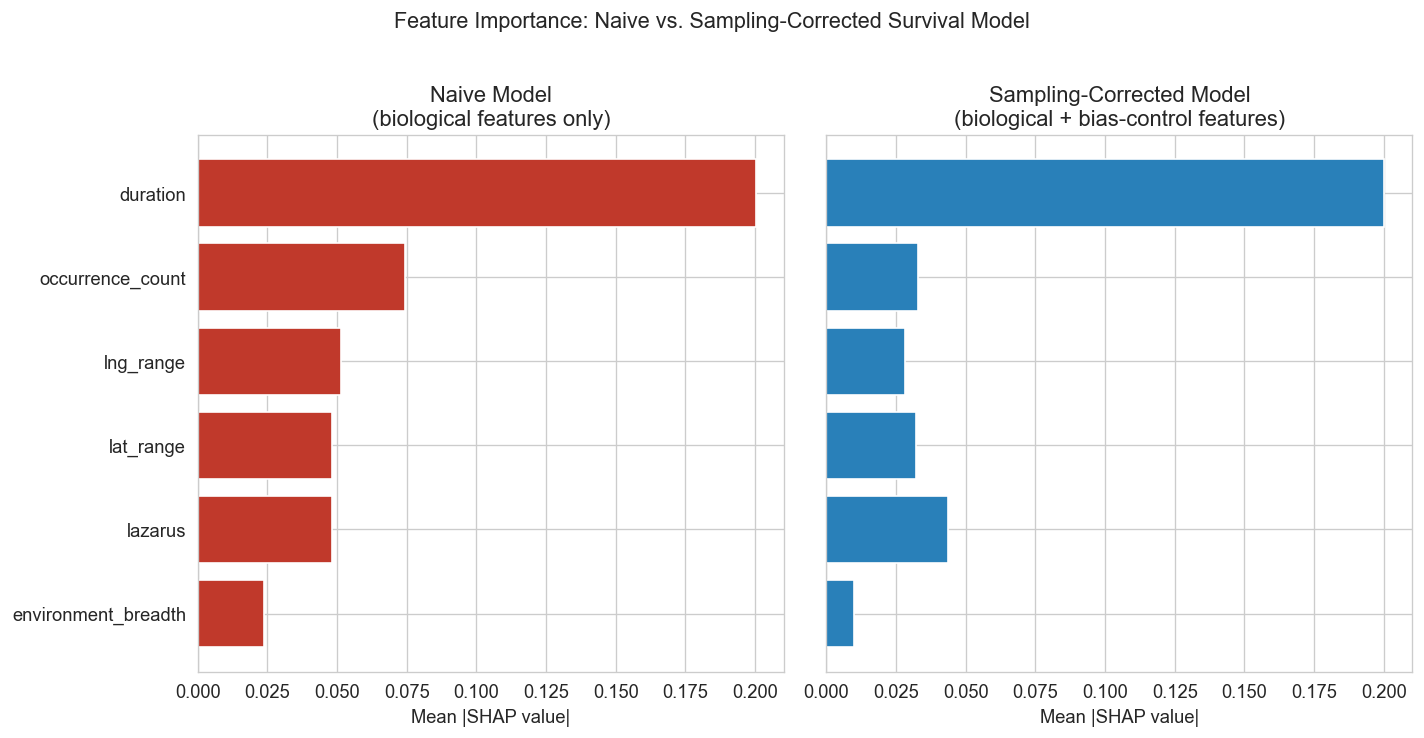

Saved: ..\results\figures\shap_naive_vs_corrected.png

--- Interpretation checklist for your report ---
For each biological feature, note whether its importance:
  (a) stayed roughly the same -> real signal, robust to sampling control
  (b) dropped sharply         -> was likely a sampling artifact in the naive model
  (c) increased               -> sampling was masking a real effect (less common, worth discussing)


In [22]:
if len(shap_naive) > 0 and len(shap_corrected) > 0:
    naive_sorted = shap_naive.sort_values("mean_abs_shap", ascending=True)
    corrected_sorted = shap_corrected.set_index("feature").reindex(
        naive_sorted["feature"]).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    axes[0].barh(naive_sorted["feature"], naive_sorted["mean_abs_shap"],
                 color="#c0392b")
    axes[0].set_title("Naive Model\n(biological features only)")
    axes[0].set_xlabel("Mean |SHAP value|")

    axes[1].barh(corrected_sorted["feature"], corrected_sorted["mean_abs_shap"],
                 color="#2980b9")
    axes[1].set_title("Sampling-Corrected Model\n(biological + bias-control features)")
    axes[1].set_xlabel("Mean |SHAP value|")

    fig.suptitle("Feature Importance: Naive vs. Sampling-Corrected Survival Model",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    out_path = FIGURES_DIR / "shap_naive_vs_corrected.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

    print("\n--- Interpretation checklist for your report ---")
    print("For each biological feature, note whether its importance:")
    print("  (a) stayed roughly the same -> real signal, robust to sampling control")
    print("  (b) dropped sharply         -> was likely a sampling artifact in the naive model")
    print("  (c) increased               -> sampling was masking a real effect (less common, worth discussing)")
else:
    print("Skipping SHAP comparison plot — run notebook 06 first.")

In [23]:
occ_path = DATA_PROCESSED / "genus_occurrences_with_labels.csv"
print(occ_path.exists())

False


In [25]:
import pandas as pd

for name, val in list(globals().items()):
    if isinstance(val, pd.DataFrame) and not name.startswith("_"):
        print(name, "->", val.shape)

diversity_df -> (4, 4)
occ_df -> (0, 6)
shap_naive -> (6, 2)
shap_corrected -> (9, 2)
naive_sorted -> (6, 2)
corrected_sorted -> (6, 2)


In [26]:
occ_path = DATA_PROCESSED / "occurrences_clean.csv"
survival_path = DATA_PROCESSED / "survival_labels_genus.csv"

have_occ = require_file(occ_path, "01_data_acquisition_cleaning.ipynb")
have_survival = require_file(survival_path, "03_survival_labels.ipynb")

if have_occ and have_survival:
    occ_raw = pd.read_csv(occ_path)
    survival = pd.read_csv(survival_path)

    # Rename to match what the map expects
    occ_raw = occ_raw.rename(columns={
        "accepted_name": "genus",
        "early_interval": "interval",
        "lat": "paleolat",   # NOTE: these are modern coordinates, not true
        "lng": "paleolng",   # paleocoordinates -- see caveat below
    })

    # Merge survival label onto each occurrence, matched on genus + interval
    occ_df = occ_raw.merge(survival, on=["genus", "interval"], how="inner")

    print("Merged shape:", occ_df.shape)
    print(occ_df[["genus", "interval", "paleolat", "paleolng", "survived"]].head())
else:
    occ_df = pd.DataFrame({
        "genus": [], "paleolat": [], "paleolng": [],
        "interval": [], "survived": []
    })

Merged shape: (7711, 11)
      genus       interval   paleolat    paleolng  survived
0  Terrakea  Changhsingian -41.299999  173.266663         0
1  Terrakea  Changhsingian -41.450001  173.100006         0
2  Terrakea  Changhsingian -41.459122  173.064972         0
3  Terrakea  Changhsingian -45.892578  167.957397         0
4  Terrakea  Changhsingian -45.654999  168.229996         0


In [27]:
if len(occ_df) > 0:
    interval_order = ["Changhsingian", "Griesbachian", "Dienerian", "Smithian",
                       "Spathian", "Aegean", "Bithynian"]
    # Keep only intervals that actually appear in your data, in a sensible order
    intervals_present = [i for i in interval_order if i in occ_df["interval"].unique()]
    extra_intervals = [i for i in occ_df["interval"].unique() if i not in intervals_present]
    full_order = intervals_present + sorted(extra_intervals)

    occ_df["interval"] = pd.Categorical(occ_df["interval"],
                                         categories=full_order, ordered=True)
    occ_df = occ_df.sort_values("interval")

    fig_map = px.scatter_geo(
        occ_df,
        lat="paleolat",
        lon="paleolng",
        color="survived",
        animation_frame="interval",
        hover_name="genus",
        title="Fossil Occurrences Across the Permian–Triassic Boundary"
              " (modern coordinates — paleogeographic reconstruction not applied)",
        projection="orthographic",
        opacity=0.7,
    )
    fig_map.update_layout(legend_title_text="Survived next interval")
    fig_map.write_html(str(FIGURES_DIR / "paleogeographic_map.html"))
    fig_map.show()
    print(f"Saved interactive map: {FIGURES_DIR / 'paleogeographic_map.html'}")
else:
    print("Skipping map — no occurrence data loaded yet.")

Saved interactive map: ..\results\figures\paleogeographic_map.html


In [28]:
print("Visualization outputs check:\n")
for f in [
    FIGURES_DIR / "diversity_raw_vs_corrected.png",
    FIGURES_DIR / "paleogeographic_map.html",
    FIGURES_DIR / "shap_naive_vs_corrected.png",
    PROJECT_ROOT / "src" / "dashboard_app.py",
]:
    status = "OK" if f.exists() else "MISSING"
    print(f"  [{status}] {f}")

Visualization outputs check:

  [OK] ..\results\figures\diversity_raw_vs_corrected.png
  [OK] ..\results\figures\paleogeographic_map.html
  [OK] ..\results\figures\shap_naive_vs_corrected.png
  [OK] ..\src\dashboard_app.py
